In [1]:
import jax.numpy as jnp
from jax.scipy import linalg
from jax import random
import matplotlib.pyplot as plt

from lqg.tracking import BoundedActor
from lqg import xcorr, LQG, Dynamics, Actor, System

/home/dominik/repos/cpp-proprioception/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


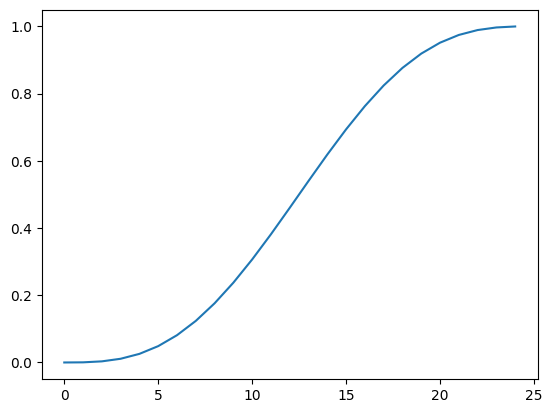

In [2]:
F_rw = 20
F_sim = 500
dt_rw = 1 / F_rw
dt_sim = 1 / F_sim
N = F_sim // F_rw

def g(t, N=50):
    return t / N - jnp.sin(2 * jnp.pi * t / N) / (2 * jnp.pi)


t = jnp.arange(N)
plt.plot(t, g(t, N=N))


In [51]:
import jax.numpy as jnp
from jax.scipy.linalg import expm
from scipy.linalg import logm
import numpy as np

EPS = 1e-12   # threshold for "near-zero" continuous A

def safe_logm_real(A):
    """
    Compute logm(A) using scipy.logm, return a real array if close to real.
    If logm fails or returns NaNs, raise RuntimeError.
    """
    L = logm(np.array(A))
    if np.any(np.isnan(L)):
        raise RuntimeError("scipy.linalg.logm produced NaNs")
    # drop tiny imaginary parts
    if np.max(np.abs(L.imag)) < 1e-10:
        L = L.real
    return jnp.array(L)

def stable_continuous_from_discrete(A_d, B_d, dt):
    """
    Robustly compute (A_c, B_c) such that e^{A_c dt} ~= A_d and
    B_d = \int_0^{dt} e^{A_c s} B_c ds.
    Handles the special-case A_d ~= I (A_c ~= 0) safely.
    """
    # Try matrix-log; if it fails, fall back to first-order approx
    try:
        A_c = safe_logm_real(A_d) / dt
    except Exception:
        # fallback: first-order
        A_c = (A_d - jnp.eye(A_d.shape[0])) / dt

    # If A_c is (near) zero, use exact closed-form B_c = B_d / dt
    if jnp.linalg.norm(A_c) < EPS:
        B_c = B_d / dt
        return A_c, B_c

    # Otherwise use robust linear solve for Bc from Bd = A_c^{-1} (A_d - I) Bc
    # rearrange: (A_c^{-1} (A_d - I)) Bc = B_d  =>  solve for Bc
    # Compute M = A_c^{-1} (A_d - I) in a stable way by solving linear system
    # A_c X = (A_d - I)  => X = solve(A_c, A_d - I)
    # then X Bc = B_d  => Bc = solve(X, B_d)
    try:
        X = jnp.linalg.solve(A_c, (A_d - jnp.eye(A_d.shape[0])))
        B_c = jnp.linalg.solve(X, B_d)
    except Exception:
        # fallback to least-squares (handles near-singular X)
        X = jnp.array(X)
        # reshape for lstsq: solve X @ Bc = Bd for Bc
        # use jax's lstsq via pseudoinverse
        X_pinv = jnp.linalg.pinv(X)
        B_c = X_pinv @ B_d

    return A_c, B_c


def van_loan_discretize(Ac, Bc, Qc, dt):
    """
    Discretize continuous-time (Ac,Bc) and process noise Qc
    via Van Loan (JAX expm).
    Returns (A_d, B_d, Qd).
    """
    n = Ac.shape[0]
    # Van Loan block for Q
    M = jnp.block([
        [Ac,            Qc],
        [jnp.zeros((n,n)), -Ac.T]
    ]) * dt
    Mexp = expm(M)
    A_d = Mexp[:n, :n]
    Q_d = A_d @ Mexp[:n, n:].T

    # B discretization (block exponential)
    m = Bc.shape[1]
    # Build (n+m) x (n+m) block with zeros arranged so expm gives integral
    M2 = jnp.block([
        [Ac,      Bc],
        [jnp.zeros((m, n)), jnp.zeros((m, m))]
    ]) * dt
    M2exp = expm(M2)
    B_d = M2exp[:n, n:n+m]

    return A_d, B_d, Q_d


def change_sampling_rate_robust(A, B, Q, R, V, dt_old, dt_new):
    """
    Robust sampling-rate change handling A ~= I case and other singularities.
    Returns (A_new, B_new, Q_cost_new, R_cost_new, V_new, Sigma_new).
    Q_cost/R_cost are the discrete-time cost matrices and will be scaled by dt_new/dt_old.
    """
    # Ensure arrays are JAX arrays
    A = jnp.array(A)
    B = jnp.array(B)
    V = jnp.array(V)

    # Qd_old = V Sigma V^T
    Qd_old = V @ V.T

    # Recover continuous-time (Ac, Bc) robustly
    Ac, Bc = stable_continuous_from_discrete(A, B, dt_old)

    # Build continuous Qc (spectral density). Use Qd_old/dt_old as robust approx.
    Qc = Qd_old / dt_old

    # Discretize at new dt using Van Loan
    A_new, B_new, Qd_new = van_loan_discretize(Ac, Bc, Qc, dt_new)

    # Scale cost matrices to preserve cost-per-time
    scale = dt_new / dt_old
    Q_cost_new = Q * scale
    R_cost_new = R * scale

    # Ensure Qd_new is PD for Cholesky; add tiny jitter if necessary
    jitter = 1e-10
    # force symmetric
    Qd_new = 0.5 * (Qd_new + Qd_new.T)
    # add jitter until cholesky succeeds (small loop)
    max_tries = 5
    for i in range(max_tries):
        try:
            V_new = jnp.linalg.cholesky(Qd_new + jitter * jnp.eye(Qd_new.shape[0]))
            break
        except Exception:
            jitter *= 10.0
    else:
        # as a last resort use SVD-based sqrt
        s, U = jnp.linalg.eigh(Qd_new)
        s_clipped = jnp.clip(s, a_min=1e-16)
        V_new = (U * jnp.sqrt(s_clipped))  # columns scaled by sqrt(eigvals)

    return A_new, B_new, Q_cost_new, R_cost_new, V_new


<>:24: SyntaxWarning: invalid escape sequence '\i'
<>:24: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_44150/3762585283.py:24: SyntaxWarning: invalid escape sequence '\i'
  B_d = \int_0^{dt} e^{A_c s} B_c ds.


In [ ]:
params = {"process_noise": 1.0, "sigma_target": 6.0, "sigma_cursor": 6.0, "action_variability": 0.5, "action_cost": 0.01}


In [88]:
A, B, Q, R, V = change_sampling_rate_robust(
    A=jnp.array([[1.0, 0.0, dt_sim], [0.0, 1.0, 0], [0.0, 0.0, 1.0]]),
    B=jnp.array([[0.0], [dt_sim], [0.0]]),
    V=jnp.diag(
        jnp.array(
            [
                params["process_noise"] / jnp.sqrt(N),
                params["action_variability"] / jnp.sqrt(N),
                0.5,
            ]
        )
    ),
    Q=linalg.block_diag(jnp.array([[1.0, -1.0], [-1.0, 1.0]]) / N, jnp.array([[0.0]])),
    R=jnp.eye(1) * params["action_cost"] / N,
    dt_old=dt_sim,
    dt_new=dt_rw,
)
A

Array([[1.  , 0.  , 0.05],
       [0.  , 1.  , 0.  ],
       [0.  , 0.  , 1.  ]], dtype=float32)

In [92]:
V

Array([[1.0026008 , 0.        , 0.        ],
       [0.        , 0.5       , 0.        ],
       [0.15584464, 0.        , 2.4951377 ]], dtype=float32)

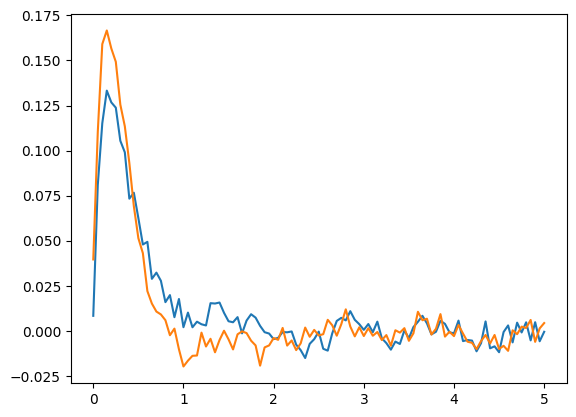

In [ ]:
A = jnp.eye(2)
B = jnp.array([[0], [dt_rw]])
V = jnp.diag(jnp.array([params["process_noise"], params["action_variability"]]))
W = jnp.diag(jnp.array([params["sigma_target"], params["sigma_cursor"]]))
Q = jnp.array([[1.0, -1.0], [-1.0, 1.0]])
R = jnp.eye(1) * params["action_cost"]

lqg_rw = System(
    dynamics=Dynamics(A=A, B=B, F=jnp.eye(2), V=V, W=W, T=500),
    actor=Actor(A=A, B=B, V=V, F=jnp.eye(2), W=W, Q=Q, R=R, T=500),
)

A_new = A
B_new = B / N
V_new = V / jnp.sqrt(N)
W_new = W * jnp.sqrt(N)
Q_new = Q / N
R_new = R / N

dynamics_sim = Dynamics(A=A_new, B=B_new, V=V_new, F=jnp.eye(2), W=W_new, T=N * 500)

A_subj = jnp.array([[1.0, 0., dt_sim], [0.0, 1.0, 0], [0.0, 0.0, 1.0]])
B_subj = jnp.array([[0.0], [dt_sim], [0.]])
V_subj = jnp.diag(jnp.array([params["process_noise"] / jnp.sqrt(N), params["action_variability"] / jnp.sqrt(N), 0.5]))
W_subj = jnp.diag(jnp.array([params["sigma_target"] * jnp.sqrt(N), params["sigma_cursor"] * jnp.sqrt(N)]))
Q_subj = linalg.block_diag(Q_new, jnp.array([[0.]]))
R_subj = R_new

actor_sim = Actor(A=A_subj, B=B_subj, V=V_subj, F=jnp.eye(2, 3), W=W_subj, Q=Q_subj, R=R_subj, T=N * 500)
lqg_sim = System(dynamics=dynamics_sim, actor=actor_sim)


# A_subj = jnp.array([[1.0, 0., dt_sim], [0.0, 1.0, 0], [0.0, 0.0, 1.0]])
# B_subj = jnp.array([[0.0], [dt_sim], [0.]])
# V_subj = jnp.diag(jnp.array([params["process_noise"] / jnp.sqrt(N), params["action_variability"] / jnp.sqrt(N), 0.]))
# Q_subj = linalg.block_diag(Q, jnp.array([[0.]]))

x_rw = lqg_rw.simulate(n=50, rng_key=random.PRNGKey(99999))
x_sim = lqg_sim.simulate(n=50, rng_key=random.PRNGKey(99999))
x_sim = x_sim[:, ::N]



(-0.1, 1.0)

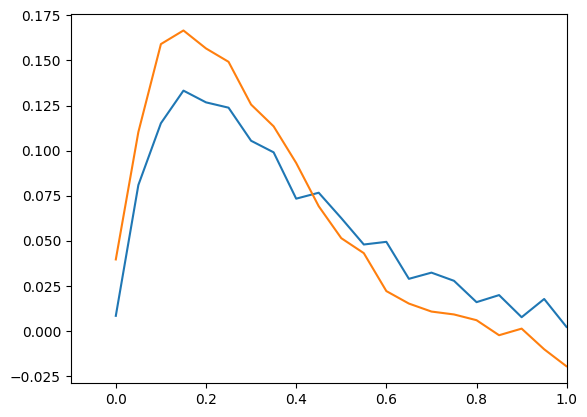

In [85]:
for x in [x_rw, x_sim]:
    vels = jnp.diff(x, axis=-2)

    # plt.plot(x[0, :, 0])  # position
    # plt.plot(x[0, :, 1])  # response
    lags, correls = xcorr(vels[..., 1], vels[..., 0], maxlags=100)

    plt.plot(lags[100:] * dt_rw, correls.mean(axis=0)[100:])

plt.xlim(-.1, 1.)

In [93]:
from cppp.models import CorrelatedObservationSubjectiveActor